# Fandango и рейтинги фильмов: проверка на завышение

В октябре 2015 года FiveThirtyEight опубликовал разбор с обвинением в адрес Fandango -
сайта, который одновременно показывает рейтинги фильмов и продаёт билеты в кино.
Суть претензии: оценки на Fandango подозрительно высокие, а отображаемые звёзды
не совпадают с реальным рейтингом.

Конфликт интересов тут очевидный. Площадка зарабатывает на билетах, а рейтинг -
это то, что человек видит за секунду до решения идти или не идти. Соблазн
округлить в свою пользу большой.

Здесь я проверяю это утверждение статистически, разделяю два обвинения:

1. **Смещение отображения.** Fandango показывает не тот рейтинг, который посчитал.
2. **Смещение самой оценки.** Даже до округления рейтинг Fandango выше, чем у
   независимых площадок на тех же фильмах.

Третий вопрос: **если завышение есть, одинаково ли оно для всех фильмов?** Коммерческая логика подсказывает, что
завышать сильнее всего имеет смысл провальные фильмы - хороший фильм продаст себя и без помощи

---

**Данные:** [fivethirtyeight/data/fandango](https://github.com/fivethirtyeight/data/tree/master/fandango),
выгрузка от 24 августа 2015 года

## Подготовка

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
rng = np.random.default_rng(SEED)

ALPHA = 0.05          
N_BOOTSTRAP = 10_000  

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_DIR = Path("data") if Path("data/fandango_scrape.csv").exists() else Path(".")
print("Данные читаем из:", DATA_DIR.resolve())

Данные читаем из: C:\DA\fandango-service\data


## Данные

Два файла. `fandango_scrape.csv` — то, что было спаршено со страниц самого Fandango:
отображаемые звёзды (`STARS`), рейтинг из разметки страницы (`RATING`) и число
голосов. `all_sites_scores.csv` — оценки тех же фильмов на пяти независимых
площадках.

Именно наличие двух разных полей `STARS` и `RATING` в первом файле и делает
возможной проверку первой гипотезы: у нас есть и то, что сайт посчитал, и то,
что он показал.

In [2]:
fandango = pd.read_csv(DATA_DIR / "fandango_scrape.csv")
all_sites = pd.read_csv(DATA_DIR / "all_sites_scores.csv")

print(f"fandango_scrape:   {fandango.shape[0]} фильмов, {fandango.shape[1]} колонки")
print(f"all_sites_scores:  {all_sites.shape[0]} фильмов, {all_sites.shape[1]} колонок")
print()
print("Пропуски:", fandango.isna().sum().sum(), "и", all_sites.isna().sum().sum())
print("Дубли по названию:", fandango["FILM"].duplicated().sum(),
      "и", all_sites["FILM"].duplicated().sum())

fandango.head()

fandango_scrape:   504 фильмов, 4 колонки
all_sites_scores:  146 фильмов, 8 колонок

Пропуски: 0 и 0
Дубли по названию: 1 и 0


,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.000,3.900,34846
1,Jurassic World (2015),4.500,4.500,34390
2,American Sniper (2015),5.000,4.800,34085
3,Furious 7 (2015),5.000,4.800,33538
4,Inside Out (2015),4.500,4.500,15749


### Фильмы без отзывов

Первое, что бросается в глаза при взгляде на распределение голосов - часть фильмов
имеет ноль голосов, при этом у них проставлены звёзды

In [3]:
n_zero_votes = (fandango["VOTES"] == 0).sum()
print(f"Фильмов с нулём голосов: {n_zero_votes} из {len(fandango)}")
print("Что у них со звёздами:")
print(fandango.loc[fandango["VOTES"] == 0, ["STARS", "RATING"]].describe().T)

fan_reviewed = fandango[fandango["VOTES"] > 0].copy()
print(f"\nОсталось для анализа: {len(fan_reviewed)} фильмов")

Фильмов с нулём голосов: 69 из 504
Что у них со звёздами:
        count  mean   std   min   25%   50%   75%   max
STARS  69.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
RATING 69.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000

Осталось для анализа: 435 фильмов


In [4]:
fan_reviewed["YEAR"] = fan_reviewed["FILM"].str.extract(r"\((\d{4})\)").astype("Int64")
print(fan_reviewed["YEAR"].value_counts().sort_index())

YEAR
2014     24
2015    410
2016      1
Name: count, dtype: Int64


## Гипотеза 1: округление

**H₀:** Fandango округляет рейтинг до звёзд честно, то есть до ближайшей половины
**H₁:** округление смещено вверх

Двойная проверка:

Первая - При честном округлении до ближайшей половины разница
`STARS − RATING` физически не может выйти за пределы ±0.25. Если находятся фильмы
с разницей 0.3, 0.4, 0.5 - это уже не округление, а надбавка

Вторая - Даже оставаясь внутри ±0.25, округление может быть
систематически смещено: вверх округляют, вниз - нет

In [8]:
fan_reviewed["STARS_DIFF"] = (fan_reviewed["STARS"] - fan_reviewed["RATING"]).round(2)

n_up = (fan_reviewed["STARS_DIFF"] > 0).sum()
n_down = (fan_reviewed["STARS_DIFF"] < 0).sum()
n_same = (fan_reviewed["STARS_DIFF"] == 0).sum()
n_impossible = (fan_reviewed["STARS_DIFF"].abs() > 0.25).sum()

print(f"Округлили вверх:            {n_up:>4} фильмов")
print(f"Округлили вниз:             {n_down:>4} фильмов")
print(f"Оставили как есть:          {n_same:>4} фильмов")
print(f"Разница больше 0.25 балла:  {n_impossible:>4} фильмов - честным округлением необъяснимо")
print()
print(f"Средняя надбавка:  {fan_reviewed['STARS_DIFF'].mean():+.4f} балла")
print(f"Максимальная:      {fan_reviewed['STARS_DIFF'].max():+.2f} балла")

Округлили вверх:             328 фильмов
Округлили вниз:                0 фильмов
Оставили как есть:           107 фильмов
Разница больше 0.25 балла:   180 фильмов - честным округлением необъяснимо

Средняя надбавка:  +0.2117 балла
Максимальная:      +1.00 балла


In [11]:
n_changed = n_up + n_down
binom_res = stats.binomtest(k=int(n_up), n=int(n_changed), p=0.5, alternative="two-sided")

print(f"Округление что-то изменило у {n_changed} фильмов, из них вверх - {n_up}")
print(f"Доля округлений вверх: {n_up / n_changed:.1%} (при честном округлении ожидаем ~50%)")
print(f"Биномиальный тест: p-value = {binom_res.pvalue:.3e}")
print(f"95% ДИ для доли:  {binom_res.proportion_ci(confidence_level=0.95)}")
print()
print("Вывод:", "H0 отвергнута - округление смещено вверх"
      if binom_res.pvalue < ALPHA else "оснований отвергнуть H0 нет")

Округление что-то изменило у 328 фильмов, из них вверх - 328
Доля округлений вверх: 100.0% (при честном округлении ожидаем ~50%)
Биномиальный тест: p-value = 3.658e-99
95% ДИ для доли:  ConfidenceInterval(low=0.9888164226978021, high=1.0)

Вывод: H0 отвергнута - округление смещено вверх


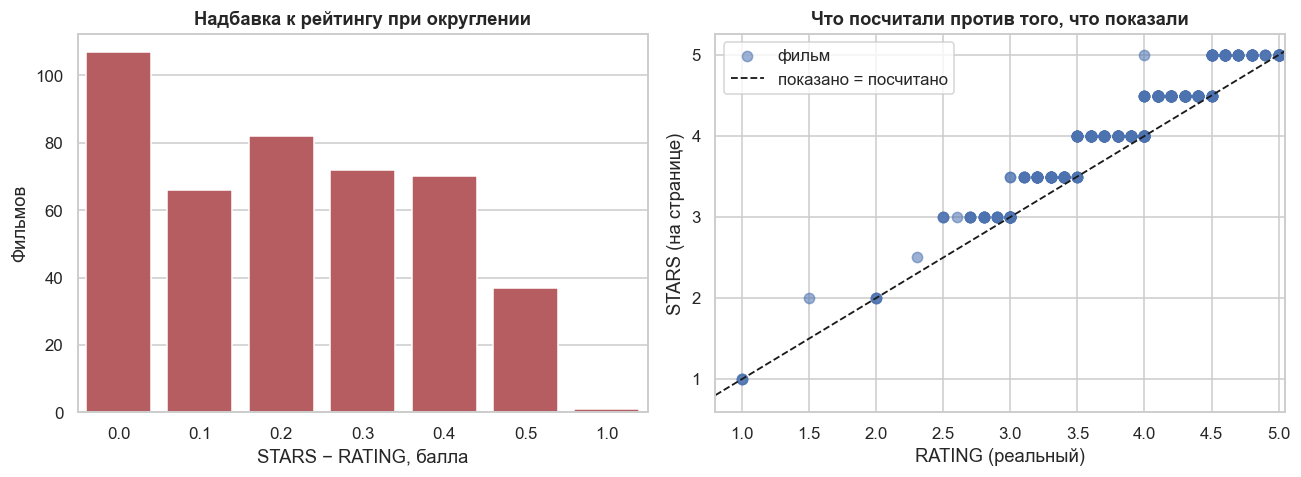

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x="STARS_DIFF", data=fan_reviewed, color="#C44E52", ax=axes[0])
axes[0].set_title("Надбавка к рейтингу при округлении")
axes[0].set_xlabel("STARS − RATING, балла")
axes[0].set_ylabel("Фильмов")

axes[1].scatter(fan_reviewed["RATING"], fan_reviewed["STARS"],
                alpha=0.55, s=45, color="#4C72B0", label="фильм")
lims = [fan_reviewed["RATING"].min() - 0.2, 5.05]
axes[1].plot(lims, lims, "k--", lw=1.2, label="показано = посчитано")
axes[1].set_xlim(lims)
axes[1].set_title("Что посчитали против того, что показали")
axes[1].set_xlabel("RATING (реальный)")
axes[1].set_ylabel("STARS (на странице)")
axes[1].legend()

plt.tight_layout()
plt.show()

Правый график: точек ниже диагонали нет вовсе. Если бы округление
было техническим, они распределились бы по обе стороны примерно поровну.

## Гипотеза 2: уровень оценки

**H₀:** медиана рейтинга Fandango равна медиане площадки-конкурента на тех же фильмах.
**H₁:** рейтинги различаются.

### Как сравнивать

**Объединяем по названию фильма.** Данные парные: каждый фильм оценён и Fandango,
и конкурентами

**Приводим к общей шкале.** Rotten Tomatoes и Metacritic живут в 0–100,
пользовательские оценки Metacritic и IMDb - в 0–10, Fandango - в 0–5.
Делим на 20 и на 2 соответственно

**Берём непараметрический критерий.** Распределения оценок скошены и упираются
в потолок шкалы, нормальности нет. Wilcoxon signed-rank работает
с парными данными и не требует нормальности. Парный t-тест посчитаю рядом как
контроль - если оба сходятся, вывод устойчив

In [12]:
df = fan_reviewed.merge(all_sites, on="FILM", how="inner")
print(f"Фильмов в пересечении двух датасетов: {len(df)}")

df["RT_norm"] = df["RottenTomatoes"] / 20
df["RTU_norm"] = df["RottenTomatoes_User"] / 20
df["Meta_norm"] = df["Metacritic"] / 20
df["MetaU_norm"] = df["Metacritic_User"] / 2
df["IMDB_norm"] = df["IMDB"] / 2

NORM_COLS = {
    "RT_norm": "Rotten Tomatoes (критики)",
    "RTU_norm": "Rotten Tomatoes (зрители)",
    "Meta_norm": "Metacritic (критики)",
    "MetaU_norm": "Metacritic (зрители)",
    "IMDB_norm": "IMDb (зрители)",
}

summary = df[["STARS", "RATING"] + list(NORM_COLS)].describe().T
summary["IQR"] = summary["75%"] - summary["25%"]
summary[["count", "mean", "50%", "std", "IQR", "min", "max"]]

Фильмов в пересечении двух датасетов: 145


,count,mean,50%,std,IQR,min,max
STARS,145.000,4.086,4.000,0.541,1.000,3.000,5.000
RATING,145.000,3.841,3.900,0.502,0.700,2.700,4.800
RT_norm,145.000,3.032,3.150,1.508,2.900,0.250,5.000
RTU_norm,145.000,3.185,3.300,0.999,1.550,1.000,4.700
Meta_norm,145.000,2.935,2.950,0.977,1.600,0.650,4.700
MetaU_norm,145.000,3.254,3.400,0.755,0.900,1.200,4.800
IMDB_norm,145.000,3.365,3.450,0.479,0.550,2.000,4.300


Уже по средним видно, что Fandango очень странен

In [13]:
def holm_correction(pvalues):
    p = np.asarray(pvalues, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m)

    running_max = 0.0
    for rank, idx in enumerate(order):
        value = (m - rank) * p[idx]
        running_max = max(running_max, value)  
        adjusted[idx] = min(running_max, 1.0)

    return adjusted


def bootstrap_median_ci(values, n_boot=N_BOOTSTRAP, alpha=ALPHA, generator=rng):
    values = np.asarray(values, dtype=float)
    idx = generator.integers(0, len(values), size=(n_boot, len(values)))
    medians = np.median(values[idx], axis=1)
    lo, hi = np.percentile(medians, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    diff = np.sign(x[:, None] - y[None, :])
    return diff.mean()

In [14]:
rows = []
for col, label in NORM_COLS.items():
    paired_diff = (df["RATING"] - df[col]).to_numpy()

    wilcoxon = stats.wilcoxon(df["RATING"], df[col])
    ttest = stats.ttest_rel(df["RATING"], df[col])
    ci_low, ci_high = bootstrap_median_ci(paired_diff)

    rows.append({
        "Площадка": label,
        "Медиана площадки": np.median(df[col]),
        "Медиана разницы": np.median(paired_diff),
        "ДИ 95% (низ)": ci_low,
        "ДИ 95% (верх)": ci_high,
        "p (Wilcoxon)": wilcoxon.pvalue,
        "p (парный t)": ttest.pvalue,
        "Дельта Клиффа": cliffs_delta(df["RATING"], df[col]),
    })

comparison = pd.DataFrame(rows)
comparison["p (Холм)"] = holm_correction(comparison["p (Wilcoxon)"])
comparison["Значимо"] = np.where(comparison["p (Холм)"] < ALPHA, "да", "нет")

comparison[["Площадка", "Медиана площадки", "Медиана разницы",
            "ДИ 95% (низ)", "ДИ 95% (верх)",
            "p (Wilcoxon)", "p (Холм)", "Дельта Клиффа", "Значимо"]]

,Площадка,Медиана площадки,Медиана разницы,ДИ 95% (низ),ДИ 95% (верх),p (Wilcoxon),p (Холм),Дельта Клиффа,Значимо
0,Rotten Tomatoes (критики),3.150,0.800,0.250,1.150,0.000,0.000,0.229,да
1,Rotten Tomatoes (зрители),3.300,0.600,0.350,0.850,0.000,0.000,0.371,да
2,Metacritic (критики),2.950,1.050,0.700,1.200,0.000,0.000,0.551,да
3,Metacritic (зрители),3.400,0.450,0.300,0.700,0.000,0.000,0.466,да
4,IMDb (зрители),3.450,0.500,0.400,0.550,0.000,0.000,0.501,да


In [15]:
print(f"Медиана рейтинга Fandango: {df['RATING'].median():.2f}\n")
for _, r in comparison.iterrows():
    print(f"{r['Площадка']:<28} разница {r['Медиана разницы']:+.2f} "
          f"[{r['ДИ 95% (низ)']:+.2f}; {r['ДИ 95% (верх)']:+.2f}]  "
          f"p={r['p (Холм)']:.2e}  d={r['Дельта Клиффа']:+.2f}")

n_sig = (comparison["Значимо"] == "да").sum()
print(f"\nЗначимых различий после поправки Холма: {n_sig} из {len(comparison)}")

Медиана рейтинга Fandango: 3.90

Rotten Tomatoes (критики)    разница +0.80 [+0.25; +1.15]  p=2.86e-08  d=+0.23
Rotten Tomatoes (зрители)    разница +0.60 [+0.35; +0.85]  p=2.18e-15  d=+0.37
Metacritic (критики)         разница +1.05 [+0.70; +1.20]  p=1.84e-15  d=+0.55
Metacritic (зрители)         разница +0.45 [+0.30; +0.70]  p=3.39e-14  d=+0.47
IMDb (зрители)               разница +0.50 [+0.40; +0.55]  p=2.31e-19  d=+0.50

Значимых различий после поправки Холма: 5 из 5


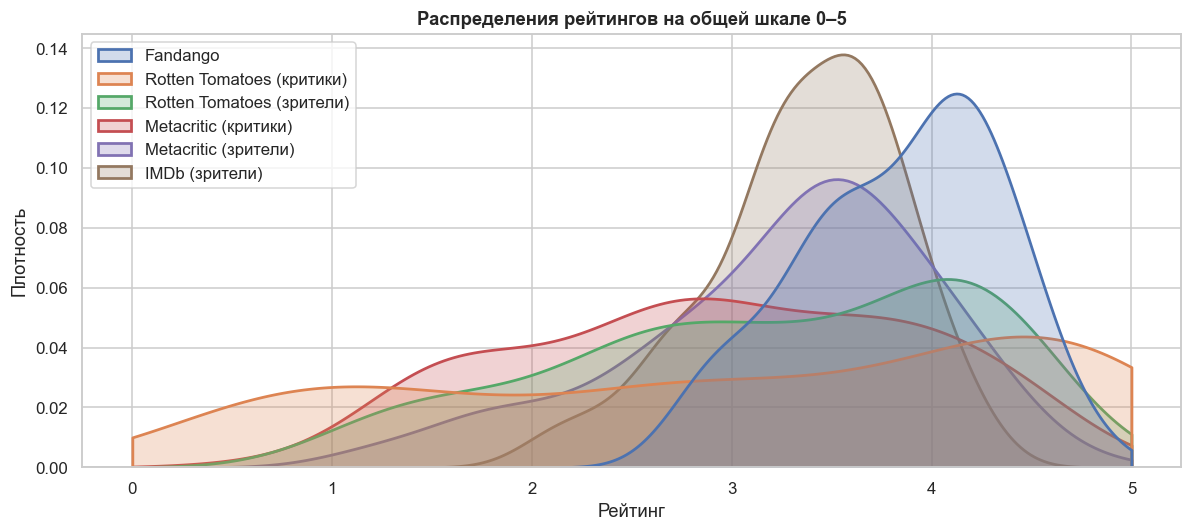

In [16]:
plot_data = df[["RATING"] + list(NORM_COLS)].rename(
    columns={"RATING": "Fandango", **NORM_COLS}
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.kdeplot(data=plot_data, clip=(0, 5), fill=True, alpha=0.25,
            linewidth=1.8, ax=ax)
ax.set_title("Распределения рейтингов на общей шкале 0–5")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("Плотность")
plt.tight_layout()
plt.show()

Кривая Fandango стоит правее всех и заметно уже: почти все фильмы упакованы
в узкий диапазон высоких оценок. Rotten Tomatoes для сравнения размазан по всей
шкале - там есть и полный провал, и восторг.

## Где завышение сильнее

Диаграмма Бланда-Альтмана: разницу сравнивают не с одним из
измерений, а со средним двух. Среднее - несмещённая оценка истинного качества
фильма, и мнимая корреляция не возникает

In [17]:
df["consensus"] = df[list(NORM_COLS)].mean(axis=1)

df["ba_mean"] = (df["RATING"] + df["consensus"]) / 2
df["ba_diff"] = df["RATING"] - df["consensus"]

bias = df["ba_diff"].mean()
sd_diff = df["ba_diff"].std(ddof=1)
loa_low, loa_high = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff

slope, intercept, r_value, p_slope, std_err = stats.linregress(
    df["ba_mean"], df["ba_diff"]
)

print(f"Систематическое смещение: {bias:+.3f} балла")
print(f"Границы согласия (95%):   [{loa_low:+.3f}; {loa_high:+.3f}]")
print()
print(f"Наклон регрессии: {slope:+.3f} (±{std_err:.3f}), p = {p_slope:.3e}, R² = {r_value**2:.3f}")
print()
if p_slope < ALPHA:
    direction = "убывает" if slope < 0 else "растёт"
    print(f"Наклон значим: разрыв {direction} с ростом качества фильма.")
    print(f"Каждый балл качества меняет разрыв на {slope:+.2f} балла.")
else:
    print("Наклон незначим: завышение примерно одинаково для фильмов любого уровня.")

Систематическое смещение: +0.687 балла
Границы согласия (95%):   [-0.859; +2.233]

Наклон регрессии: -0.716 (±0.096), p = 6.301e-12, R² = 0.282

Наклон значим: разрыв убывает с ростом качества фильма.
Каждый балл качества меняет разрыв на -0.72 балла.


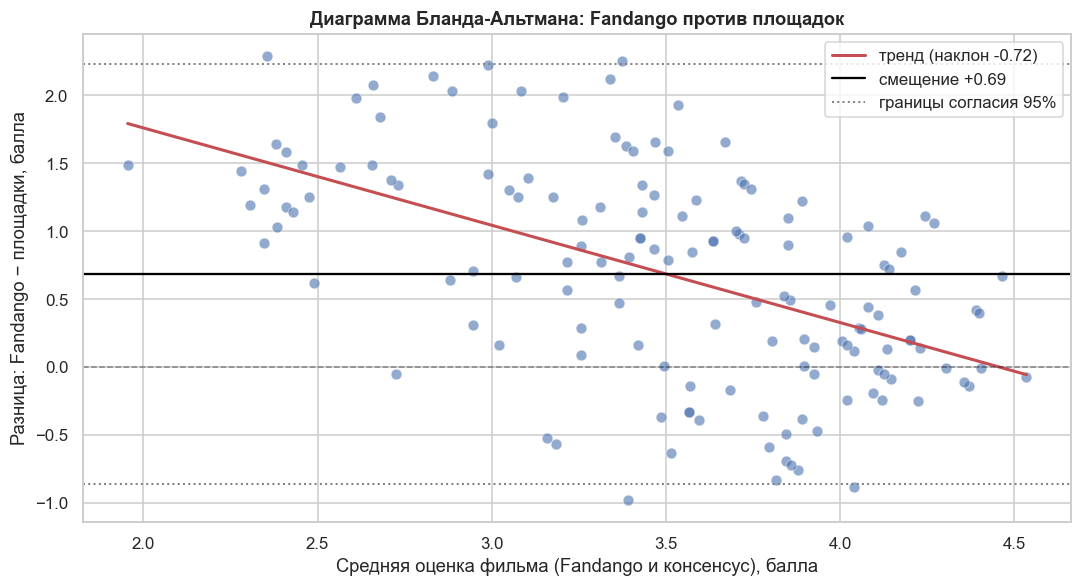

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.scatter(df["ba_mean"], df["ba_diff"], alpha=0.6, s=50,
           color="#4C72B0", edgecolor="white", linewidth=0.5)

x_line = np.linspace(df["ba_mean"].min(), df["ba_mean"].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="#C44E52", lw=2,
        label=f"тренд (наклон {slope:+.2f})")

ax.axhline(bias, color="black", lw=1.5, label=f"смещение {bias:+.2f}")
ax.axhline(loa_low, color="gray", ls=":", lw=1.3)
ax.axhline(loa_high, color="gray", ls=":", lw=1.3, label="границы согласия 95%")
ax.axhline(0, color="black", ls="--", lw=1, alpha=0.4)

ax.set_title("Диаграмма Бланда-Альтмана: Fandango против площадок")
ax.set_xlabel("Средняя оценка фильма (Fandango и консенсус), балла")
ax.set_ylabel("Разница: Fandango − площадки, балла")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [21]:
df["quality_group"] = pd.qcut(
    df["consensus"], q=4,
    labels=["Худшие 25%", "Ниже среднего", "Выше среднего", "Лучшие 25%"],
)

by_quality = df.groupby("quality_group", observed=True).agg(
    фильмов=("FILM", "count"),
    консенсус=("consensus", "mean"),
    fandango=("RATING", "mean"),
    разрыв=("ba_diff", "mean"),
)
by_quality

,фильмов,консенсус,fandango,разрыв
quality_group,,,,
Худшие 25%,37,1.965,3.514,1.548
Ниже среднего,36,2.908,3.883,0.975
Выше среднего,36,3.616,3.919,0.304
Лучшие 25%,36,4.161,4.058,-0.102


In [22]:
checks = []

threshold = int(df["VOTES"].median())
popular = df[df["VOTES"] >= threshold]
checks.append({
    "Проверка": f"Только фильмы с VOTES >= {threshold}",
    "N": len(popular),
    "Смещение": popular["ba_diff"].mean(),
    "p (Wilcoxon)": stats.wilcoxon(popular["RATING"], popular["consensus"]).pvalue,
})

for year in sorted(df["YEAR"].dropna().unique()):
    subset = df[df["YEAR"] == year]
    if len(subset) < 10:
        continue
    checks.append({
        "Проверка": f"Только фильмы {year} года",
        "N": len(subset),
        "Смещение": subset["ba_diff"].mean(),
        "p (Wilcoxon)": stats.wilcoxon(subset["RATING"], subset["consensus"]).pvalue,
    })

median_consensus = df[list(NORM_COLS)].median(axis=1)
checks.append({
    "Проверка": "Консенсус как медиана площадок",
    "N": len(df),
    "Смещение": (df["RATING"] - median_consensus).mean(),
    "p (Wilcoxon)": stats.wilcoxon(df["RATING"], median_consensus).pvalue,
})

audience_only = df[["RTU_norm", "MetaU_norm", "IMDB_norm"]].mean(axis=1)
checks.append({
    "Проверка": "Сравнение только со зрителями",
    "N": len(df),
    "Смещение": (df["RATING"] - audience_only).mean(),
    "p (Wilcoxon)": stats.wilcoxon(df["RATING"], audience_only).pvalue,
})

robustness = pd.DataFrame(checks)
robustness["Значимо"] = np.where(robustness["p (Wilcoxon)"] < ALPHA, "да", "нет")
robustness

,Проверка,N,Смещение,p (Wilcoxon),Значимо
0,Только фильмы с VOTES >= 1430,73,0.980,0.000,да
1,Только фильмы 2014 года,17,0.152,0.678,нет
2,Только фильмы 2015 года,128,0.758,0.000,да
3,Консенсус как медиана площадок,145,0.688,0.000,да
4,Сравнение только со зрителями,145,0.573,0.000,да


## Худшие фильмы

Беру десять фильмов с худшими оценками критиков Rotten Tomatoes и смотрю,
что показывал по ним Fandango

In [23]:
worst = df.nsmallest(10, "RT_norm")[
    ["FILM", "STARS", "RATING", "RT_norm", "RTU_norm",
     "Meta_norm", "MetaU_norm", "IMDB_norm", "consensus"]
].copy()
worst["разрыв"] = worst["STARS"] - worst["consensus"]
worst.set_index("FILM").round(2)

,STARS,RATING,RT_norm,RTU_norm,Meta_norm,MetaU_norm,IMDB_norm,consensus,разрыв
FILM,,,,,,,,,
Paul Blart: Mall Cop 2 (2015),3.500,3.500,0.250,1.800,0.650,1.200,2.150,1.210,2.290
Hitman: Agent 47 (2015),4.000,3.900,0.350,2.450,1.400,1.650,2.950,1.760,2.240
Hot Pursuit (2015),4.000,3.700,0.400,1.850,1.550,1.850,2.450,1.620,2.380
Taken 3 (2015),4.500,4.100,0.450,2.300,1.300,2.300,3.050,1.880,2.620
Fantastic Four (2015),3.000,2.700,0.450,1.000,1.350,1.250,2.000,1.210,1.790
The Boy Next Door (2015),4.000,3.600,0.500,1.750,1.500,2.750,2.300,1.760,2.240
Unfinished Business (2015),3.500,3.200,0.550,1.350,1.600,1.900,2.700,1.620,1.880
The Loft (2015),4.000,3.600,0.550,2.000,1.200,1.200,3.150,1.620,2.380
Seventh Son (2015),3.500,3.200,0.600,1.750,1.500,1.950,2.750,1.710,1.790


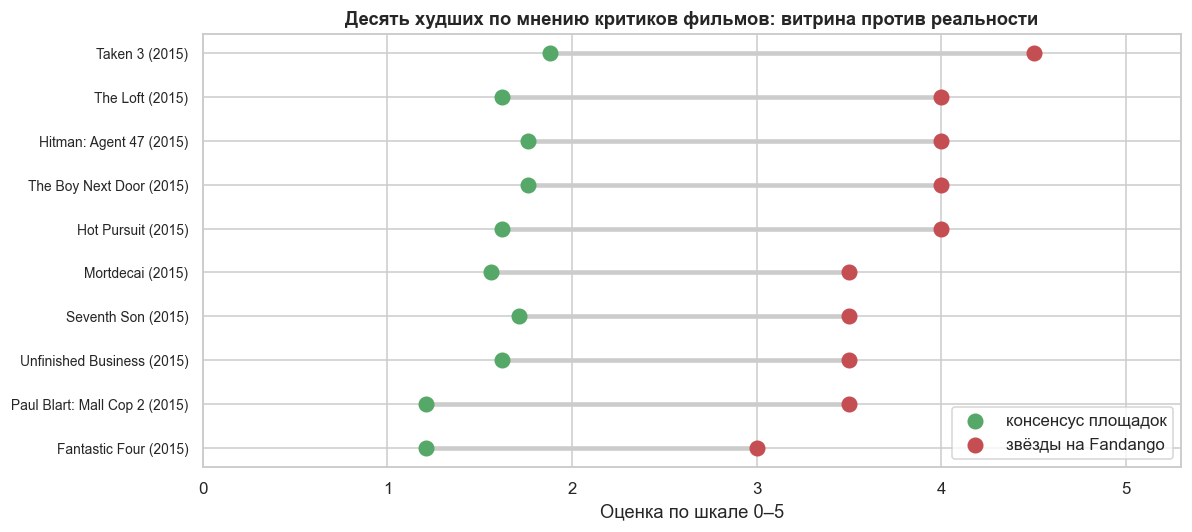

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))

plot_worst = worst.set_index("FILM")[["STARS", "consensus"]].sort_values("STARS")
y = np.arange(len(plot_worst))

ax.hlines(y, plot_worst["consensus"], plot_worst["STARS"],
          color="#CCCCCC", lw=3, zorder=1)
ax.scatter(plot_worst["consensus"], y, s=90, color="#55A868",
           label="консенсус площадок", zorder=2)
ax.scatter(plot_worst["STARS"], y, s=90, color="#C44E52",
           label="звёзды на Fandango", zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(plot_worst.index, fontsize=9)
ax.set_xlim(0, 5.3)
ax.set_xlabel("Оценка по шкале 0–5")
ax.set_title("Десять худших по мнению критиков фильмов: витрина против реальности")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [25]:
gap = worst["STARS"] - worst["consensus"]
print(f"Средний разрыв на худших фильмах:  {gap.mean():+.2f} балла")
print(f"Средний разрыв по всей выборке:    {(df['STARS'] - df['consensus']).mean():+.2f} балла")
print()
leader = worst.loc[gap.idxmax()]
print("Максимальный разрыв:")
print(f"  {leader['FILM']}")
print(f"  Fandango показывал {leader['STARS']:.1f} звезды при консенсусе {leader['consensus']:.2f}")

Средний разрыв на худших фильмах:  +2.16 балла
Средний разрыв по всей выборке:    +0.93 балла

Максимальный разрыв:
  Taken 3 (2015)
  Fandango показывал 4.5 звезды при консенсусе 1.88


## Выводы:

In [28]:
print("ИТОГИ")

print(f"\n1. ОКРУГЛЕНИЕ")
print(f"   Округлений вверх: {n_up} из {n_changed} изменённых ({n_up / n_changed:.0%})")
print(f"   Вниз не округлён ни один фильм" if n_down == 0
      else f"   Вниз округлено: {n_down}")
print(f"   Биномиальный тест: p = {binom_res.pvalue:.2e}")
print(f"   Фильмов с надбавкой больше 0.25 балла: {n_impossible}")

print(f"\n2. УРОВЕНЬ ОЦЕНКИ")
print(f"   Медиана Fandango: {df['RATING'].median():.2f}, "
      f"площадки: {df['consensus'].median():.2f}")
print(f"   Значимых различий после поправки Холма: {n_sig} из {len(comparison)}")
print(f"   Систематическое смещение: {bias:+.2f} балла")

print(f"\n3. СТРУКТУРА ЗАВЫШЕНИЯ")
if p_slope < ALPHA:
    print(f"   Наклон {slope:+.2f} значим (p = {p_slope:.2e}):")
    print(f"   разрыв тем больше, чем хуже фильм")
else:
    print(f"   Наклон незначим (p = {p_slope:.2f}): завышение равномерное")
print(f"   Разрыв на худших 25%: {by_quality['разрыв'].iloc[0]:+.2f} балла")
print(f"   Разрыв на лучших 25%: {by_quality['разрыв'].iloc[-1]:+.2f} балла")


ИТОГИ

1. ОКРУГЛЕНИЕ
   Округлений вверх: 328 из 328 изменённых (100%)
   Вниз не округлён ни один фильм
   Биномиальный тест: p = 3.66e-99
   Фильмов с надбавкой больше 0.25 балла: 180

2. УРОВЕНЬ ОЦЕНКИ
   Медиана Fandango: 3.90, площадки: 3.20
   Значимых различий после поправки Холма: 5 из 5
   Систематическое смещение: +0.69 балла

3. СТРУКТУРА ЗАВЫШЕНИЯ
   Наклон -0.72 значим (p = 6.30e-12):
   разрыв тем больше, чем хуже фильм
   Разрыв на худших 25%: +1.55 балла
   Разрыв на лучших 25%: -0.10 балла


### Что это значит

**Завышение шире, чем округление.** Рейтинг Fandango выше оценок независимых
площадок и до всякого округления, причём разрыв сохраняется при сравнении только
со зрительскими оценками 

**Завышение неравномерно.** Разрыв растёт по мере
падения качества фильма. 

Данные показывают устойчивое смещение.